In [1]:
import pandas as pd

ggg = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG.csv")

print(ggg.shape)
print(ggg.columns.tolist())

(2534, 38)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent', 'clicks_quiz', 'clicks_resource', 'clicks_subpage']


In [3]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 10)]

click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent',
              'clicks_quiz', 'clicks_resource', 'clicks_subpage']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

ggg_sel = ggg[selected_cols].copy()
print(ggg_sel.shape)
ggg_sel.head()

(2534, 25)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,ass_8_score,ass_9_score,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucontent,clicks_quiz,clicks_resource,clicks_subpage,final_result
0,M,East Midlands Region,A Level or Equivalent,80-90%,0-35,0,30,N,80.0,80.0,...,80.0,100.0,62.0,2.0,130.0,357.0,120.0,18.0,23.0,Distinction
1,M,North Western Region,Lower Than A Level,10-20,35-55,0,30,N,66.0,53.0,...,100.0,100.0,118.0,1.0,315.0,151.0,105.0,83.0,13.0,Pass
2,F,London Region,A Level or Equivalent,30-40%,0-35,0,30,N,55.0,55.0,...,80.0,NaN,140.0,0.0,181.0,178.0,88.0,18.0,15.0,Pass
3,F,East Midlands Region,Lower Than A Level,70-80%,35-55,0,30,N,80.0,70.0,...,NaN,NaN,3.0,0.0,24.0,36.0,1.0,3.0,10.0,Fail
4,F,Yorkshire Region,A Level or Equivalent,10-20,35-55,0,30,N,78.0,90.0,...,60.0,100.0,127.0,4.0,176.0,360.0,143.0,27.0,15.0,Distinction


In [5]:
print("imd_band unique values:")
print(ggg_sel['imd_band'].unique())
print()
print("imd_band NaN count:", ggg_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(ggg_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(ggg_sel[click_cols].isna().sum())

imd_band unique values:
['80-90%' '10-20' '30-40%' '70-80%' nan '40-50%' '90-100%' '50-60%'
 '0-10%' '60-70%' '20-30%']

imd_band NaN count: 7

NaN counts - assessment scores:
ass_1_score     495
ass_2_score     641
ass_3_score     810
ass_4_score     687
ass_5_score     786
ass_6_score     871
ass_7_score     901
ass_8_score    1075
ass_9_score    1325
dtype: int64

NaN counts - click columns:
clicks_forumng      168
clicks_glossary     168
clicks_homepage     168
clicks_oucontent    168
clicks_quiz         168
clicks_resource     168
clicks_subpage      168
dtype: int64


In [7]:
ggg_sel['imd_band'] = ggg_sel['imd_band'].replace('10-20', '10-20%')

imd_mode = ggg_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
ggg_sel['imd_band'] = ggg_sel['imd_band'].fillna(imd_mode)

print(ggg_sel['imd_band'].unique())

click_nan_mask = ggg_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 7])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

ggg_sel[assessment_cols] = ggg_sel[assessment_cols].fillna(-1)
ggg_sel[click_cols] = ggg_sel[click_cols].fillna(0)

print(ggg_sel.isna().sum().sum())

imd_band mode: 10-20%
['80-90%' '10-20%' '30-40%' '70-80%' '40-50%' '90-100%' '50-60%' '0-10%'
 '60-70%' '20-30%']
All-or-nothing NaN pattern across clicks: True
0


In [9]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
ggg_sel['final_result'] = ggg_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
ggg_sel['highest_education'] = ggg_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
ggg_sel['imd_band'] = ggg_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
ggg_sel['age_band'] = ggg_sel['age_band'].map(age_band_map)

ggg_sel['gender'] = ggg_sel['gender'].map({'M': 0, 'F': 1})
ggg_sel['disability'] = ggg_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ggg_sel['region'] = le.fit_transform(ggg_sel['region'])

print(ggg_sel.isna().sum().sum())
print(ggg_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
ass_8_score             float64
ass_9_score             float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucontent        float64
clicks_quiz             float64
clicks_resource         float64
clicks_subpage          float64
final_result              int64
dtype: object


In [11]:
for col in click_cols:
    nonzero = (ggg_sel[col] != 0).sum()
    unique_vals = ggg_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_forumng: 1892 nonzero / 411 unique values
clicks_glossary: 1131 nonzero / 67 unique values
clicks_homepage: 2364 nonzero / 404 unique values
clicks_oucontent: 2277 nonzero / 598 unique values
clicks_quiz: 1989 nonzero / 248 unique values
clicks_resource: 2322 nonzero / 166 unique values
clicks_subpage: 2280 nonzero / 118 unique values


In [13]:
ggg_sel['total_clicks'] = ggg_sel[click_cols].sum(axis=1)
ggg_sel = ggg_sel.drop(columns=click_cols)

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(ggg_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    ggg_sel[col] = binned.cat.codes

print()
print("Final shape:", ggg_sel.shape)
print(ggg_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 2 bins
ass_5_score: 2 bins
ass_6_score: 2 bins
ass_7_score: 2 bins
ass_8_score: 3 bins
ass_9_score: 1 bins
total_clicks: 4 bins

Final shape: (2534, 19)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'final_result', 'total_clicks']


In [15]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = ggg_sel.values.astype(float)
node_names = ggg_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_ggg = [f'ass_{i}_score' for i in range(1, 10)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_ggg + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3
for i in range(1, 10):
    for j in range(1, 10):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5
for a in assessment_cols_ggg:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6
for a in assessment_cols_ggg:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/19 [00:00<?, ?it/s]

PC complete.
Number of edges: 30


In [17]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

imd_band --> region
disability --> region
age_band --> highest_education
disability --> highest_education
age_band --> total_clicks
num_of_prev_attempts --- studied_credits
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_6_score
ass_3_score --> ass_5_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_7_score
total_clicks --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> ass_7_score
total_clicks --> ass_5_score
ass_6_score --> final_result
ass_7_score --> ass_8_score
ass_7_score --> final_result
total_clicks --> ass_7_score
ass_8_score --> final_result
total_clicks --> ass_8_score
total_clicks --> final_result


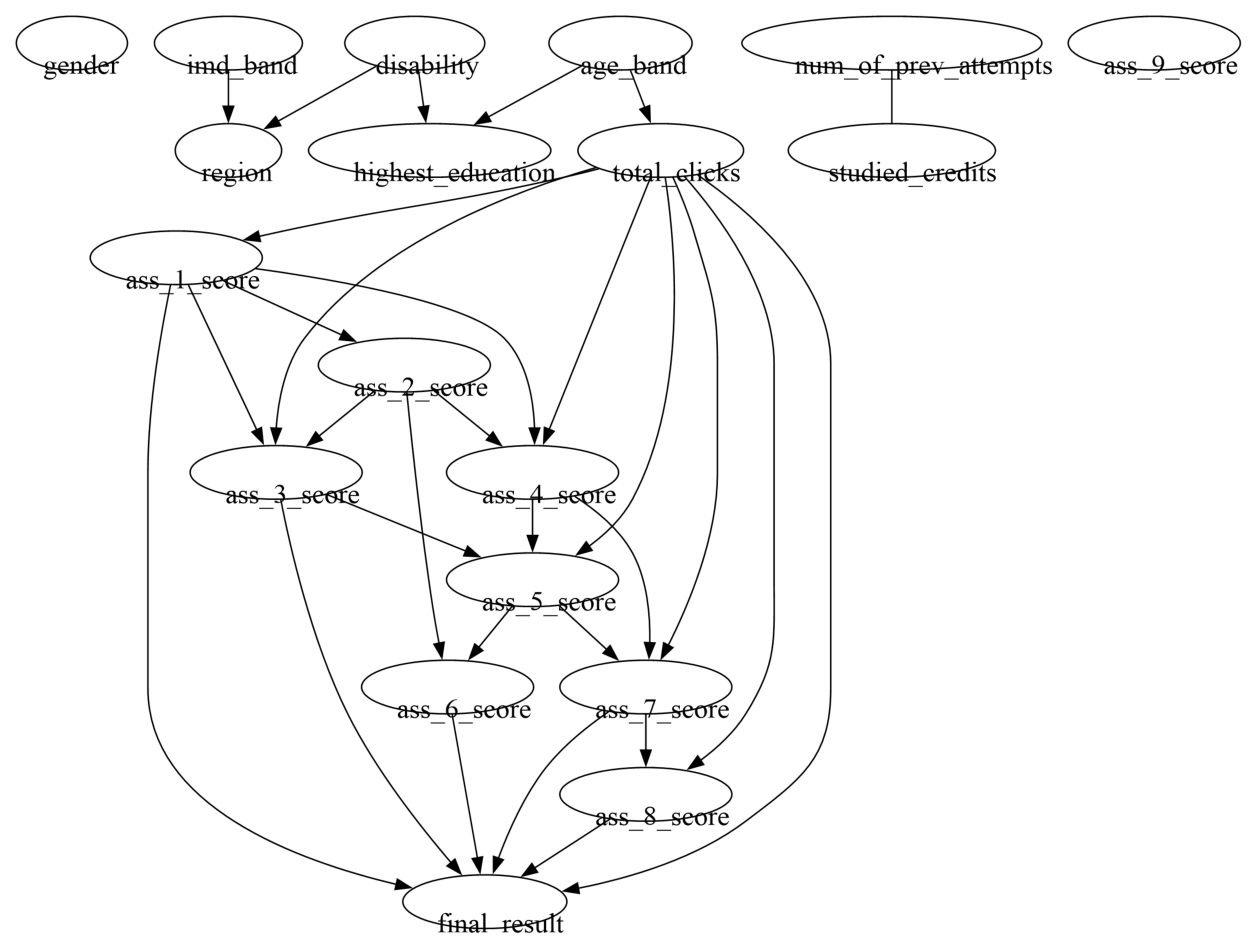

In [19]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()